In [1]:
# ======================
# 1. IMPORT LIBRARIES
# ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


In [3]:
# ======================
# 2. LOAD DATA
# ======================

data = pd.read_excel(r"../df.xlsx")

# Remove unwanted rows
df = data.iloc[27:, :]

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort values by date
df = df.sort_values('Date')

# Set Date as index
df.set_index('Date', inplace=True)

# Target variable
ts = df['Production']

In [ ]:
# ======================
# 3. CREATE LAG FEATURES
# ======================

df_rf = pd.DataFrame(ts)

# Create lag variables
df_rf['lag1'] = df_rf['Production'].shift(1)
df_rf['lag2'] = df_rf['Production'].shift(2)
df_rf['lag3'] = df_rf['Production'].shift(3)

# Remove missing values
df_rf.dropna(inplace=True)



In [5]:
# ======================
# 4. DEFINE X AND y
# ======================

X = df_rf[['lag1', 'lag2', 'lag3']]

y = df_rf['Production']

In [6]:
# ======================
# 5. TRAIN / TEST SPLIT
# ======================

train_size = int(len(df_rf) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

In [9]:
# ======================
# 6. BUILD RANDOM FOREST MODEL
# ======================

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [10]:
# ======================
# 7. PREDICTIONS
# ======================

y_pred = rf_model.predict(X_test)
y_pred

array([1659.31233219, 2255.11353801, 1440.85565857, 2375.84700873,
       1392.59613321, 2038.40152039, 2297.88837262, 1209.44712984,
       1534.43872222, 2356.26998381, 1455.87596259, 2682.60207206,
       2281.84519512])

In [11]:
# ======================
# 8. MODEL EVALUATION
# ======================

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# R² Score
r2 = r2_score(y_test, y_pred)

# Correlation
correlation = np.corrcoef(y_test, y_pred)[0,1]

# Print evaluation metrics
print("===================================")
print(" RANDOM FOREST MODEL EVALUATION")
print("===================================")

print(f"RMSE        : {rmse:.2f}")
print(f"MAE         : {mae:.2f}")
print(f"MAPE        : {mape:.2f}%")
print(f"R² Score    : {r2:.4f}")
print(f"Correlation : {correlation:.4f}")

 RANDOM FOREST MODEL EVALUATION
RMSE        : 650.67
MAE         : 510.34
MAPE        : 22.78%
R² Score    : -0.4210
Correlation : 0.4126


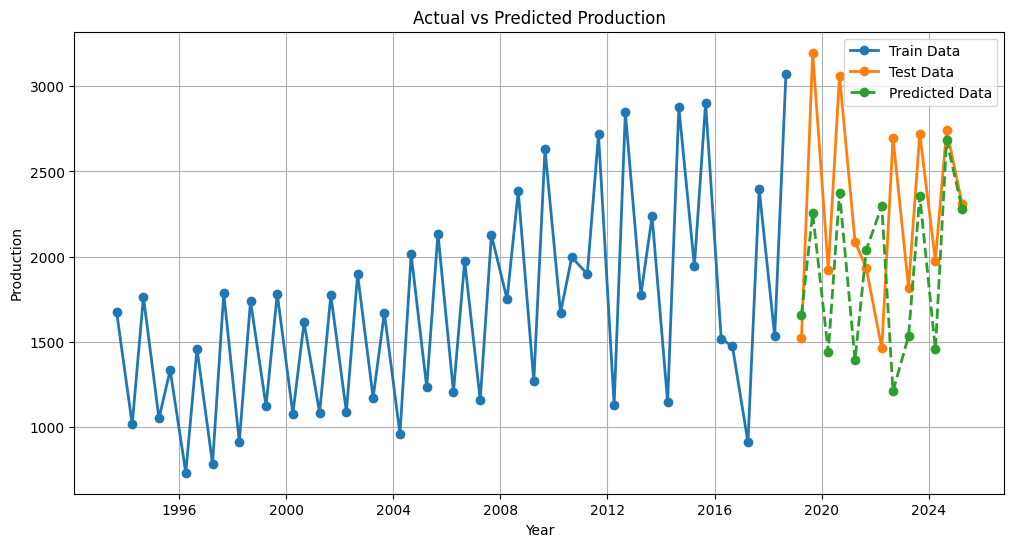

In [12]:
# ======================
# 9. ACTUAL VS PREDICTED PLOT
# ======================

plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label='Train Data',
    marker='o',
    linewidth=2
)

plt.plot(
    y_test.index,
    y_test,
    label='Test Data',
    marker='o',
    linewidth=2
)

plt.plot(
    y_test.index,
    y_pred,
    label='Predicted Data',
    marker='o',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Production")

plt.title("Actual vs Predicted Production")

plt.legend()

plt.grid(True)

plt.show()


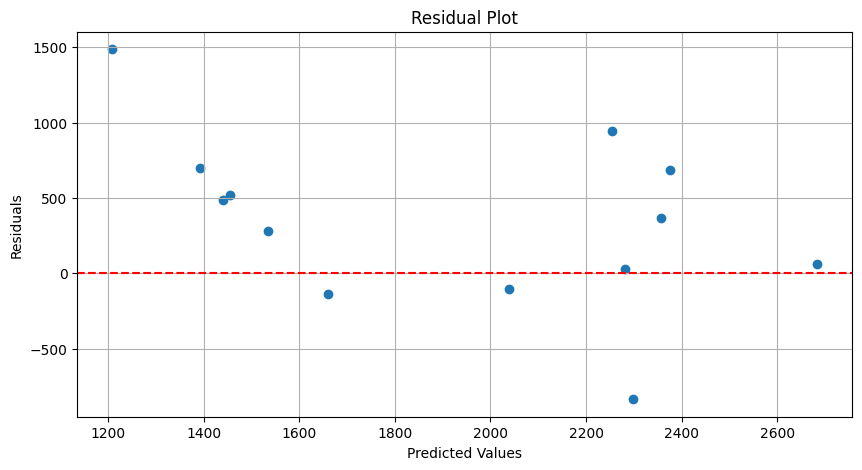

In [13]:
# ======================
# 10. RESIDUAL ANALYSIS
# ======================

residuals = y_test - y_pred

plt.figure(figsize=(10,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [14]:
# ======================
# 11. FEATURE IMPORTANCE
# ======================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

print("\nFeature Importance")
print(importance)


Feature Importance
  Feature  Importance
0    lag1    0.157253
1    lag2    0.706874
2    lag3    0.135873


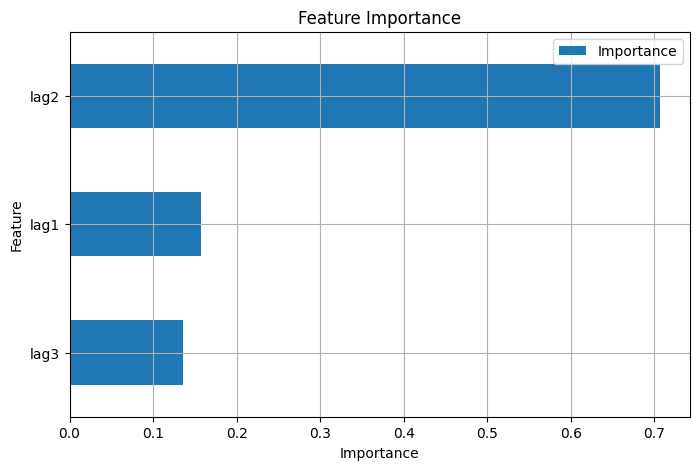

In [15]:

# ======================
# 12. FEATURE IMPORTANCE PLOT
# ======================

importance.sort_values('Importance').plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)

plt.xlabel("Importance")

plt.title("Feature Importance")

plt.grid(True)

plt.show()


In [17]:

# # ======================
# # 13. FUTURE FORECASTING
# # ======================

# future_forecast = []

# # Get last 3 observations
# last_values = list(ts.tail(3))

# # Forecast next 5 years
# for i in range(5):

#     # Prepare input
#     X_future = np.array(last_values[-3:]).reshape(1, -1)

#     # Predict next value
#     next_pred = rf_model.predict(X_future)[0]

#     # Store prediction
#     future_forecast.append(next_pred)

#     # Update lag values
#     last_values.append(next_pred)


# # ======================
# # 14. CREATE FUTURE DATES
# # ======================

# future_dates = pd.date_range(
#     start=ts.index[-1] + pd.DateOffset(years=1),
#     periods=5,
#     freq='Y'
# )


# # ======================
# # 15. FORECAST DATAFRAME
# # ======================

# forecast_df = pd.DataFrame({
#     'Date': future_dates,
#     'Forecast': future_forecast
# })

# print("\nFuture Forecast")
# print(forecast_df)


# # ======================
# # 16. PLOT FORECAST
# # ======================

# plt.figure(figsize=(12,6))

# # Historical data
# plt.plot(
#     ts.index,
#     ts,
#     label='Historical Data',
#     marker='o',
#     linewidth=2
# )

# # Forecast values
# plt.plot(
#     forecast_df['Date'],
#     forecast_df['Forecast'],
#     label='Forecast',
#     marker='o',
#     linestyle='--',
#     linewidth=2
# )

# plt.xlabel("Year")
# plt.ylabel("Production")

# plt.title("Random Forest Future Forecast")

# plt.legend()

# plt.grid(True)

# plt.show()